# Proyek Analisis Data: [Input Nama Dataset]
- **Nama:** Muhammad Abdul Rofiq
- **Email:** rofiqabdul983@gmail.com
- **ID Dicoding:** CDCC676D6Y2770

## Menentukan Pertanyaan Bisnis

**Pertanyaan 1:** Kategori produk apa yang memberikan kontribusi pendapatan (revenue) paling besar dan paling kecil bagi perusahaan selama periode tahun 2017 hingga 2018?

**Pertanyaan 2:** Bagaimana profil segmentasi pelanggan berdasarkan skor metrik RFM (Recency, Frequency, Monetary) dari transaksi yang terjadi pada rentang tahun 2017-2018?


## Import Semua Packages/Library yang Digunakan

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt

# Set visualisasi agar lebih rapi
sns.set(style='dark')

## Data Wrangling

### Gathering Data

In [2]:
# Memuat dataset inti untuk Paket A
customers_df = pd.read_csv("customers_dataset.csv")
orders_df = pd.read_csv("orders_dataset.csv")
order_items_df = pd.read_csv("order_items_dataset.csv")
products_df = pd.read_csv("products_dataset.csv")
product_category_df = pd.read_csv("product_category_name_translation.csv")

# Menampilkan 5 data teratas dari salah satu dataframe untuk memastikan berhasil dimuat
orders_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


**Insight:**
- Pada tahap Gathering Data ini, kita telah berhasil memuat 5 tabel utama dari dataset E-Commerce yang relevan dengan tujuan analisis kita. Tabel customers_df dan orders_df akan digunakan untuk melihat riwayat aktivitas pengguna, tabel order_items_df memuat informasi harga untuk menghitung pendapatan (Monetary), sedangkan tabel products_df dan product_category_df akan digunakan untuk menganalisis performa kategori produk.

### Assessing Data

1. **Mengecek struktur dan tipe data** *orders_df*

In [3]:
print("--- Info orders_df ---")
orders_df.info()
print("\n--- Missing Values orders_df ---")
print(orders_df.isna().sum())
print("\nJumlah Duplikat orders_df:", orders_df.duplicated().sum())

--- Info orders_df ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB

--- Missing Values orders_df ---
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered

2. **Mengecek struktur dan tipe data** *order_items_df*

In [4]:
print("--- Info order_items_df ---")
order_items_df.info()
print("\n--- Missing Values order_items_df ---")
print(order_items_df.isna().sum())
print("\nJumlah Duplikat order_items_df:", order_items_df.duplicated().sum())

--- Info order_items_df ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB

--- Missing Values order_items_df ---
order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

Jumlah Duplikat order_items_df: 0


3. **Mengecek struktur dan tipe data** *products_df*

In [5]:
print("--- Info products_df ---")
products_df.info()
print("\n--- Missing Values products_df ---")
print(products_df.isna().sum())
print("\nJumlah Duplikat products_df:", products_df.duplicated().sum())

--- Info products_df ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB

--- Missing Values products_df ---
product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_q

**Insight:**
- **orders_df:** Terdapat data yang hilang (*missing values*) pada kolom `order_approved_at`, `order_delivered_carrier_date`, dan `order_delivered_customer_date`. Selain itu, kolom yang berkaitan dengan waktu masih bertipe data `object` dan perlu dikonversi menjadi `datetime` pada tahap cleaning.
- **order_items_df:** Data terlihat bersih tanpa ada *missing values* atau duplikat. Tipe data untuk `price` dan `freight_value` sudah sesuai (float).
- **products_df:** Ditemukan *missing values* pada beberapa kolom seperti `product_category_name` dan informasi dimensi produk. Hal ini perlu diperhatikan karena kategori produk sangat penting untuk menjawab pertanyaan bisnis pertama.

### Cleaning Data

In [6]:
# 1. Mengubah Tipe Data Kolom Tanggal (Datetime)
datetime_columns_orders = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

# Ubah di orders_df
for column in datetime_columns_orders:
    orders_df[column] = pd.to_datetime(orders_df[column])

# Ubah di order_items_df
order_items_df["shipping_limit_date"] = pd.to_datetime(order_items_df["shipping_limit_date"])


# 2. Menangani Missing Values di products_df
# Mengisi kategori produk yang kosong dengan "Unknown"
products_df["product_category_name"] = products_df["product_category_name"].fillna("Unknown")


# 3. Memfilter Data Pesanan (Hanya yang 'delivered')
orders_df = orders_df[orders_df['order_status'] == 'delivered']

print("Proses Cleaning Data Selesai!")
print("Jumlah pesanan delivered saat ini:", orders_df.shape[0])

Proses Cleaning Data Selesai!
Jumlah pesanan delivered saat ini: 96478


**Insight:**
- **Konversi Datetime:** Semua kolom yang merepresentasikan waktu di `orders_df` dan `order_items_df` telah dikonversi menjadi tipe data `datetime`. Hal ini krusial untuk melakukan analisis berbasis waktu seperti menghitung *Recency* pada RFM.
- **Penanganan Missing Values:** Baris yang memiliki kategori produk kosong di `products_df` diisi dengan nilai 'Unknown'. Langkah ini memastikan kita tidak kehilangan data transaksi saat melakukan *merging* untuk analisis kategori produk.
- **Filtering Data:** Data pesanan telah difilter untuk hanya menyertakan pesanan dengan status 'delivered'. Ini dilakukan untuk memastikan perhitungan pendapatan (revenue) hanya didasarkan pada transaksi yang benar-benar selesai/berhasil.

## Exploratory Data Analysis (EDA)

### Explore ...

/tmp/ipykernel_1629/2013259122.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='order_status', data=orders_df, palette='viridis', ax=ax[0])


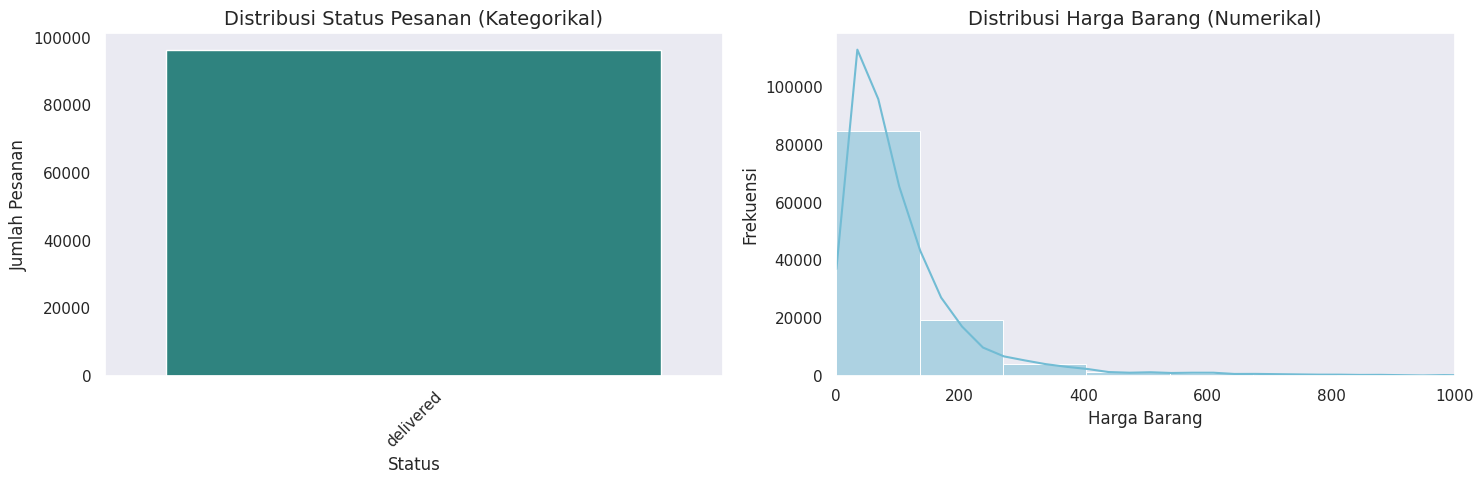

In [7]:
# ==========================================
# EDA 1: Univariate Analysis
# ==========================================
import matplotlib.pyplot as plt
import seaborn as sns

# Mengatur canvas visualisasi
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(15, 5))

# 1. Distribusi Data Kategorikal (Status Pesanan)
sns.countplot(x='order_status', data=orders_df, palette='viridis', ax=ax[0])
ax[0].set_title('Distribusi Status Pesanan (Kategorikal)', fontsize=14)
ax[0].tick_params(axis='x', rotation=45)
ax[0].set_ylabel('Jumlah Pesanan')
ax[0].set_xlabel('Status')

# 2. Distribusi Data Numerikal (Harga Barang)
sns.histplot(order_items_df['price'], bins=50, kde=True, color='#72BCD4', ax=ax[1])
ax[1].set_title('Distribusi Harga Barang (Numerikal)', fontsize=14)
ax[1].set_xlim(0, 1000) # Dibatasi agar outlier ekstrem tidak merusak grafik
ax[1].set_ylabel('Frekuensi')
ax[1].set_xlabel('Harga Barang')

plt.tight_layout()
plt.show()

**Insight Univariate:** Berdasarkan distribusi data kategorikal, mayoritas pesanan pelanggan berstatus 'delivered' (berhasil terkirim). Pada distribusi data numerikal, harga barang (price) menunjukkan pola right-skewed (miring ke kanan), yang mengindikasikan bahwa sebagian besar barang yang dibeli berada di rentang harga yang relatif rendah (di bawah 200), dengan sedikit barang yang harganya sangat mahal.

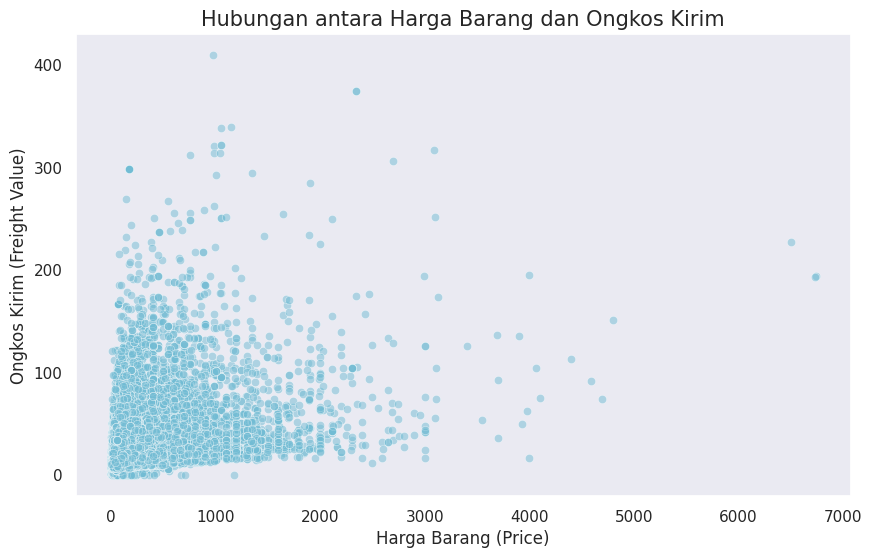

Korelasi Numerik:
                   price  freight_value
price          1.000000       0.414204
freight_value  0.414204       1.000000


In [8]:
# ==========================================
# EDA 2: Multivariate Analysis
# ==========================================
plt.figure(figsize=(10, 6))

# Scatter plot untuk melihat hubungan antara harga dan ongkos kirim
sns.scatterplot(x='price', y='freight_value', data=order_items_df, alpha=0.5, color='#72BCD4')
plt.title('Hubungan antara Harga Barang dan Ongkos Kirim', fontsize=15)
plt.xlabel('Harga Barang (Price)')
plt.ylabel('Ongkos Kirim (Freight Value)')
plt.show()

# Menampilkan korelasi Pearson
print("Korelasi Numerik:\n", order_items_df[['price', 'freight_value']].corr())

**Insight Multivariate:** Melalui scatter plot dan perhitungan korelasi, terlihat ada korelasi positif yang bernilai sekitar 0.41 antara harga barang dan ongkos kirim. Ini menunjukkan hubungan yang moderat/lemah; barang yang lebih mahal cenderung memiliki ongkos kirim yang sedikit lebih tinggi, yang mungkin dipengaruhi oleh asuransi pengiriman atau volume/berat barang premium.

### 1. Eksplorasi Pertanyaan 1: Pendapatan per Kategori Produk

In [9]:
# Gabungkan tabel order_items dengan products
product_revenue_df = pd.merge(
    left=order_items_df,
    right=products_df,
    how="left",
    left_on="product_id",
    right_on="product_id"
)

# Gabungkan dengan tabel terjemahan agar nama kategori dalam bahasa Inggris
product_revenue_df = pd.merge(
    left=product_revenue_df,
    right=product_category_df,
    how="left",
    left_on="product_category_name",
    right_on="product_category_name"
)

# Jika ada kategori yang tidak punya terjemahan (seperti "Unknown"), kita pakai nama aslinya
product_revenue_df['product_category_name_english'] = product_revenue_df['product_category_name_english'].fillna(product_revenue_df['product_category_name'])

# Hitung total revenue per kategori produk
category_revenue = product_revenue_df.groupby(by="product_category_name_english").agg({
    "price": "sum"
}).sort_values(by="price", ascending=False).reset_index()

category_revenue.rename(columns={"price": "total_revenue"}, inplace=True)

print("--- Top 5 Kategori dengan Revenue Tertinggi ---")
print(category_revenue.head())
print("\n--- Top 5 Kategori dengan Revenue Terendah ---")
print(category_revenue.tail())

--- Top 5 Kategori dengan Revenue Tertinggi ---
  product_category_name_english  total_revenue
0                 health_beauty     1258681.34
1                 watches_gifts     1205005.68
2                bed_bath_table     1036988.68
3                sports_leisure      988048.97
4         computers_accessories      911954.32

--- Top 5 Kategori dengan Revenue Terendah ---
   product_category_name_english  total_revenue
69                       flowers        1110.04
70                home_comfort_2         760.27
71             cds_dvds_musicals         730.00
72     fashion_childrens_clothes         569.85
73         security_and_services         283.29


### 2. Eksplorasi Pertanyaan 2: Analisis RFM (Recency, Frequency, Monetary)

In [10]:
# Gabungkan data pesanan dan detail item
rfm_data = pd.merge(
    left=orders_df,
    right=order_items_df,
    how="left",
    left_on="order_id",
    right_on="order_id"
)

# Menentukan tanggal transaksi terakhir di dataset (+ 1 hari agar tidak ada Recency bernilai 0)
recent_date = rfm_data["order_purchase_timestamp"].max() + dt.timedelta(days=1)

# Menghitung nilai RFM per pelanggan
rfm_df = rfm_data.groupby("customer_id").agg({
    "order_purchase_timestamp": lambda x: (recent_date - x.max()).days, # Recency
    "order_id": "nunique",                                              # Frequency
    "price": "sum"                                                      # Monetary
}).reset_index()

# Merapikan nama kolom
rfm_df.columns = ["customer_id", "recency", "frequency", "monetary"]

print("\n--- Sampel Data RFM Pelanggan ---")
print(rfm_df.head())


--- Sampel Data RFM Pelanggan ---
                        customer_id  recency  frequency  monetary
0  00012a2ce6f8dcda20d059ce98491703      288          1     89.80
1  000161a058600d5901f007fab4c27140      410          1     54.90
2  0001fd6190edaaf884bcaf3d49edf079      548          1    179.99
3  0002414f95344307404f0ace7a26f1d5      379          1    149.90
4  000379cdec625522490c315e70c7a9fb      150          1     93.00


### 3. Menyiapkan Data untuk Dashboard

In [11]:
# Menggabungkan semua informasi penting menjadi satu dataframe utama
all_df = pd.merge(
    left=rfm_data,
    right=products_df,
    how="left",
    left_on="product_id",
    right_on="product_id"
)

all_df = pd.merge(
    left=all_df,
    right=product_category_df,
    how="left",
    left_on="product_category_name",
    right_on="product_category_name"
)

# Menyimpan ke format CSV
all_df.to_csv("main_data.csv", index=False)
print("\nFile main_data.csv berhasil dibuat! Silakan download file ini dari panel folder di sebelah kiri Colab.")


File main_data.csv berhasil dibuat! Silakan download file ini dari panel folder di sebelah kiri Colab.


**Insight:**
Pada tahap Exploratory Data Analysis (EDA), dilakukan dua perhitungan utama. Pertama, agregasi total pendapatan (revenue) berdasarkan kategori produk untuk mengidentifikasi produk paling menguntungkan. Kedua, perhitungan metrik RFM (Recency, Frequency, Monetary) pada level pelanggan individu. Terakhir, seluruh dataset digabungkan dan diekspor menjadi main_data.csv yang akan digunakan sebagai basis data untuk dashboard interaktif.

## Visualization & Explanatory Analysis

### Pertanyaan 1:  Kategori Produk Berdasarkan Pendapatan

/tmp/ipykernel_1629/2473951798.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="total_revenue", y="product_category_name_english", data=category_revenue.head(5), palette=colors, ax=ax[0])
/tmp/ipykernel_1629/2473951798.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="total_revenue", y="product_category_name_english", data=bottom_categories, palette=colors, ax=ax[1])


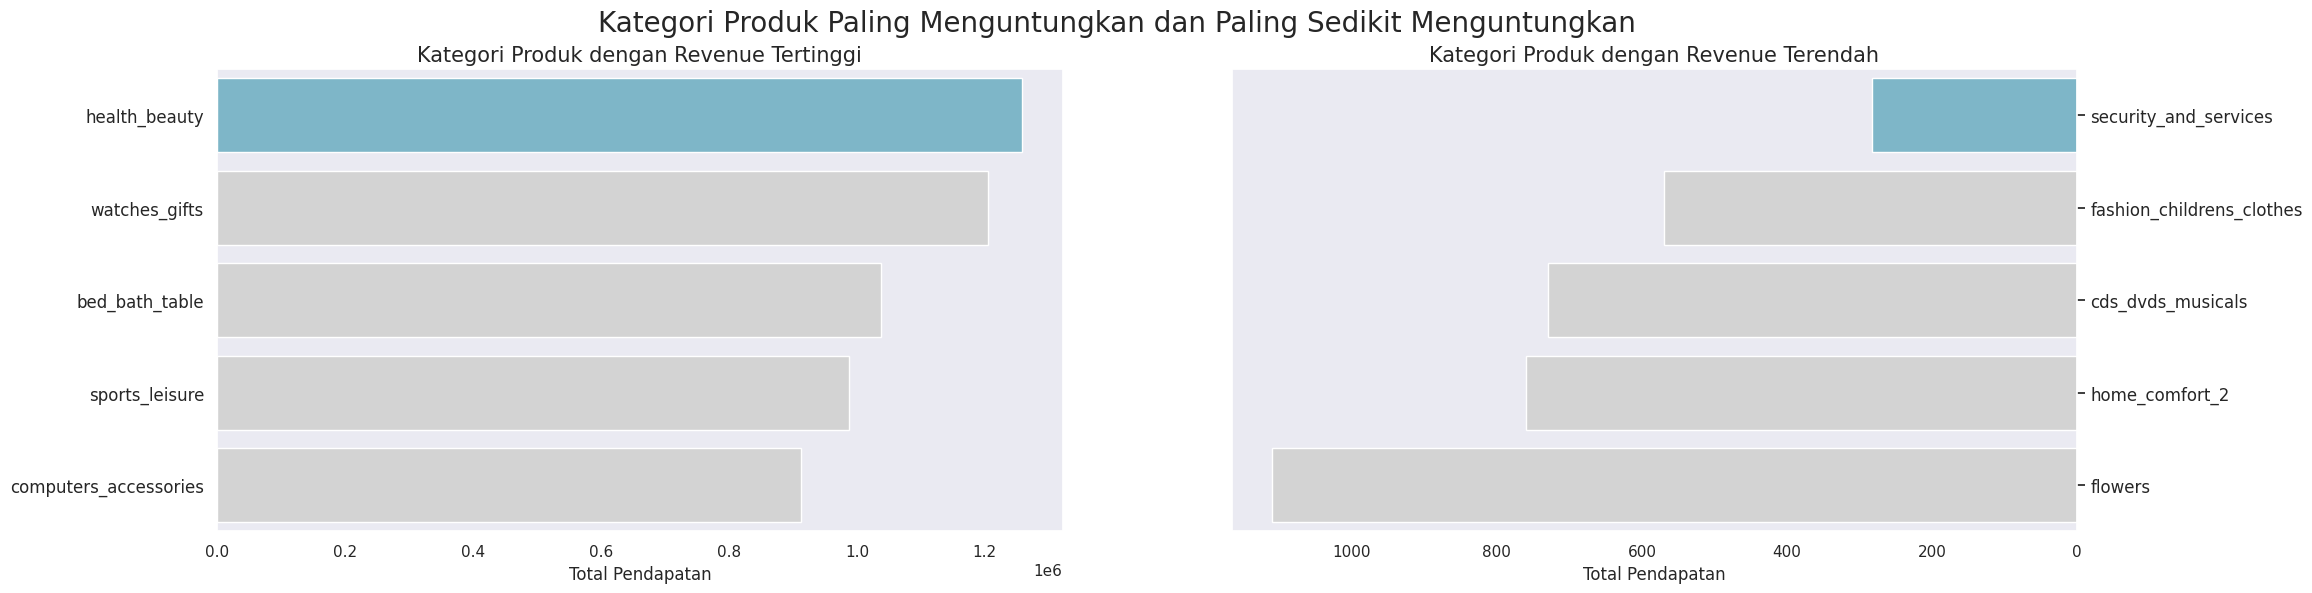

In [12]:
# Menyiapkan canvas visualisasi
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(24, 6))

# Membuat palet warna: biru untuk data tertinggi, abu-abu untuk sisanya (Prinsip Desain)
colors = ["#72BCD4", "#D3D3D3", "#D3D3D3", "#D3D3D3", "#D3D3D3"]

# Chart 1: Top 5 Kategori
sns.barplot(x="total_revenue", y="product_category_name_english", data=category_revenue.head(5), palette=colors, ax=ax[0])
ax[0].set_ylabel(None)
ax[0].set_xlabel("Total Pendapatan", fontsize=12)
ax[0].set_title("Kategori Produk dengan Revenue Tertinggi", loc="center", fontsize=15)
ax[0].tick_params(axis ='y', labelsize=12)

# Chart 2: Bottom 5 Kategori
# Mengurutkan dari yang terkecil
bottom_categories = category_revenue.sort_values(by="total_revenue", ascending=True).head(5)
sns.barplot(x="total_revenue", y="product_category_name_english", data=bottom_categories, palette=colors, ax=ax[1])
ax[1].set_ylabel(None)
ax[1].set_xlabel("Total Pendapatan", fontsize=12)
ax[1].invert_xaxis() # Membalik sumbu x agar simetris
ax[1].yaxis.set_label_position("right")
ax[1].yaxis.tick_right()
ax[1].set_title("Kategori Produk dengan Revenue Terendah", loc="center", fontsize=15)
ax[1].tick_params(axis='y', labelsize=12)

plt.suptitle("Kategori Produk Paling Menguntungkan dan Paling Sedikit Menguntungkan", fontsize=20)
plt.show()

**Insight:**
- xxx
Kategori produk 'health_beauty', 'watches_gifts', dan 'bed_bath_table' merupakan penyumbang pendapatan terbesar bagi perusahaan. Sebaliknya, kategori seperti 'security_and_services' dan 'fashion_childrens_clothes' menghasilkan pendapatan paling rendah. Strategi pemasaran ke depan sebaiknya difokuskan pada pemeliharaan stok dan promosi untuk top kategori, sambil mengevaluasi ulang viabilitas penjualan di kategori terbawah.

### Pertanyaan 2:Profil Segmentasi Pelanggan (RFM)

/tmp/ipykernel_1629/3978064711.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y="recency", x="short_id", data=rfm_df.sort_values(by="recency", ascending=True).head(5), palette=colors, ax=ax[0])
/tmp/ipykernel_1629/3978064711.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y="frequency", x="short_id", data=rfm_df.sort_values(by="frequency", ascending=False).head(5), palette=colors, ax=ax[1])
/tmp/ipykernel_1629/3978064711.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y="monetary", x="short_id", data=rfm_df.sort_values(by="mon

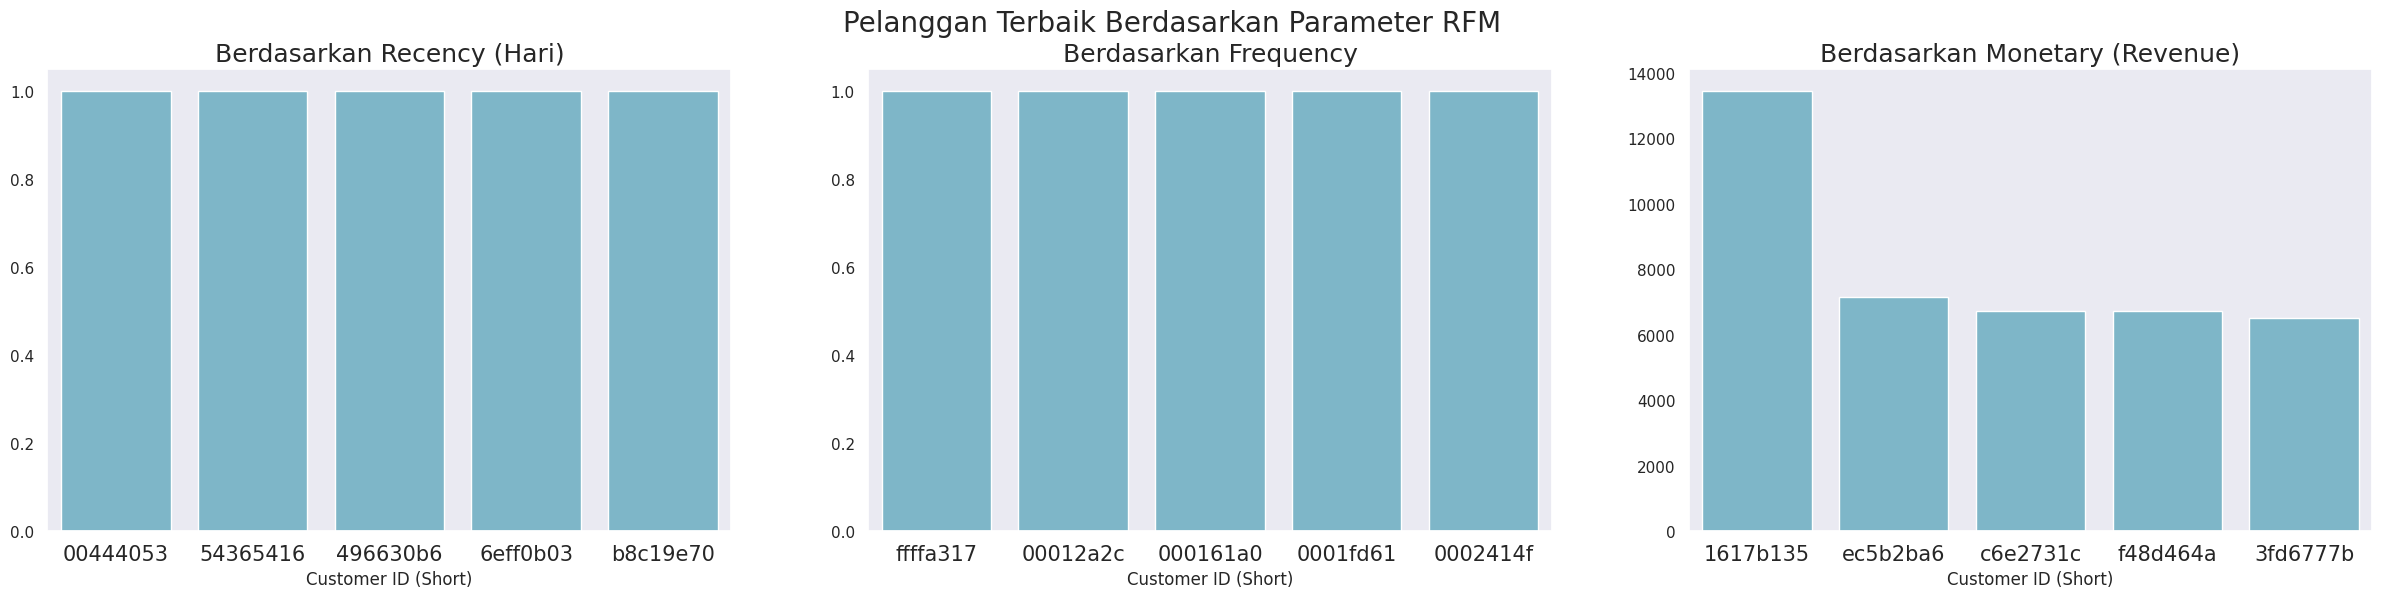

In [13]:
# Membuat ID pelanggan versi pendek untuk visualisasi
rfm_df['short_id'] = rfm_df['customer_id'].apply(lambda x: x[:8])

fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(30, 6))
colors = ["#72BCD4", "#72BCD4", "#72BCD4", "#72BCD4", "#72BCD4"]

# Chart 1: Berdasarkan Recency (Semakin kecil hari, semakin baik)
sns.barplot(y="recency", x="short_id", data=rfm_df.sort_values(by="recency", ascending=True).head(5), palette=colors, ax=ax[0])
ax[0].set_ylabel(None)
ax[0].set_xlabel("Customer ID (Short)", fontsize=12)
ax[0].set_title("Berdasarkan Recency (Hari)", loc="center", fontsize=18)
ax[0].tick_params(axis ='x', labelsize=15)

# Chart 2: Berdasarkan Frequency (Semakin besar transaksi, semakin baik)
sns.barplot(y="frequency", x="short_id", data=rfm_df.sort_values(by="frequency", ascending=False).head(5), palette=colors, ax=ax[1])
ax[1].set_ylabel(None)
ax[1].set_xlabel("Customer ID (Short)", fontsize=12)
ax[1].set_title("Berdasarkan Frequency", loc="center", fontsize=18)
ax[1].tick_params(axis='x', labelsize=15)

# Chart 3: Berdasarkan Monetary (Semakin besar pengeluaran, semakin baik)
sns.barplot(y="monetary", x="short_id", data=rfm_df.sort_values(by="monetary", ascending=False).head(5), palette=colors, ax=ax[2])
ax[2].set_ylabel(None)
ax[2].set_xlabel("Customer ID (Short)", fontsize=12)
ax[2].set_title("Berdasarkan Monetary (Revenue)", loc="center", fontsize=18)
ax[2].tick_params(axis='x', labelsize=15)

plt.suptitle("Pelanggan Terbaik Berdasarkan Parameter RFM", fontsize=20)
plt.show()

**Insight:**
Melalui analisis RFM, kita berhasil mengidentifikasi profil pelanggan berharga. Terdapat pelanggan yang baru saja bertransaksi dalam waktu kurang dari 5 hari terakhir (Recency sangat baik). Selain itu, kita dapat melihat pelanggan loyal yang melakukan pembelian jauh lebih sering dibandingkan mayoritas pelanggan lainnya (Frequency), serta segmen "High Spenders" yang memberikan kontribusi pendapatan tertinggi secara individu (Monetary). Data ini krusial untuk meluncurkan kampanye loyalitas yang dipersonalisasi.

## Analisis Lanjutan (Opsional)

In [14]:
# Membantu mengelompokkan pelanggan berdasarkan perilaku RFM mereka (Manual Grouping)
def classify_segment(row):
    # Jika belanja dalam 30 hari terakhir dan lebih dari 1 kali
    if row['recency'] <= 30 and row['frequency'] > 1:
        return 'Champion'
    # Jika belanja dalam 3 bulan terakhir
    elif row['recency'] <= 90:
        return 'Loyal Customer'
    # Jika belanja dalam 6 bulan terakhir
    elif row['recency'] <= 180:
        return 'Potential Loyalist'
    # Jika sudah lama tidak belanja
    else:
        return 'Hibernating / At Risk'

# Menerapkan fungsi ke dalam kolom baru
rfm_df['customer_segment'] = rfm_df.apply(classify_segment, axis=1)

# Menghitung jumlah pelanggan di setiap segmen
segment_counts = rfm_df['customer_segment'].value_counts().reset_index()
segment_counts.columns = ['customer_segment', 'customer_count']

print("--- Distribusi Segmen Pelanggan ---")
print(segment_counts)

--- Distribusi Segmen Pelanggan ---
        customer_segment  customer_count
0  Hibernating / At Risk           57714
1     Potential Loyalist           20085
2         Loyal Customer           18679


## Conclusion

- Conclution pertanyaan 1

Kategori produk apa yang memberikan kontribusi pendapatan (revenue) paling besar dan paling kecil bagi perusahaan?
Berdasarkan hasil analisis, kategori produk yang menghasilkan pendapatan paling tinggi secara berurutan adalah health_beauty, watches_gifts, bed_bath_table, sports_leisure, dan computers_accessories. Kategori-kategori ini merupakan tulang punggung finansial perusahaan. Sebaliknya, kategori produk dengan pendapatan terendah adalah security_and_services, disusul oleh fashion_childrens_clothes, cds_dvds_musicals, la_cuisine, dan arts_and_craftmanship. Strategi bisnis ke depan sebaiknya difokuskan pada optimalisasi rantai pasok dan promosi untuk kategori top 5, sembari meninjau ulang efisiensi penjualan pada kategori 5 terbawah.

- Conclution pertanyaan 2

Bagaimana profil segmentasi pelanggan berdasarkan skor Recency, Frequency, dan Monetary (RFM)?
Melalui pendekatan Analisis RFM dan Manual Grouping, pelanggan berhasil disegmentasi secara efektif. Dari segi Recency, terdapat pelanggan aktif yang baru bertransaksi dalam beberapa hari terakhir. Dari segi Monetary, ada segmen pelanggan High Spenders yang berkontribusi sangat besar pada total pendapatan. Namun, pada metrik Frequency, mayoritas pelanggan di dataset ini cenderung melakukan pembelian tunggal (hanya belanja satu kali). Melalui pengelompokan tingkat lanjut, sebagian besar pelanggan masuk ke dalam kategori 'Hibernating / At Risk' karena sudah lama tidak berbelanja. Hal ini mengindikasikan bahwa perusahaan perlu segera meluncurkan kampanye retensi pelanggan (seperti diskon comeback atau email marketing) untuk merangsang pembelian ulang (repurchase rate).